# Nhận diện khuôn mặt bằng Google Colab

**Yêu cầu bài:** code Colab nhận diện khuôn mặt qua ảnh, nộp notebook lên GitHub, nộp file dữ liệu và quay video demo.  
**Lưu ý:** Notebook này **không làm app/web**, chỉ train và test mô hình trực tiếp trên Google Colab.

Quy trình chính:
1. Upload file dữ liệu `.zip`.
2. Giải nén và chuẩn hóa thư mục ảnh.
3. Chia dữ liệu thành train/validation/test.
4. Train mô hình nhận diện khuôn mặt bằng transfer learning.
5. Đánh giá bằng accuracy, classification report và confusion matrix.
6. Upload ảnh mới để dự đoán thử.
7. Lưu model và các file kết quả.

## Bước 1: Import thư viện và kiểm tra GPU

Trước khi chạy, nên vào **Runtime → Change runtime type → Hardware accelerator → GPU**.

In [1]:
import os
import re
import json
import shutil
import zipfile
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Bước 2: Upload file dữ liệu `.zip`

Chọn file dữ liệu khuôn mặt dạng `.zip`. Có thể dùng file đã chuẩn hóa `face_dataset_clean_39classes.zip` hoặc file zip gốc.

In [2]:
from google.colab import files

# Nếu trong /content chưa có file zip thì Colab sẽ yêu cầu upload.
zip_files = sorted(Path('/content').glob('*.zip'))

if not zip_files:
    print("Hãy chọn file dữ liệu .zip để upload")
    uploaded = files.upload()
    zip_files = sorted(Path('/content').glob('*.zip'))

if not zip_files:
    raise FileNotFoundError("Chưa tìm thấy file .zip nào. Hãy chạy lại cell này và upload dataset.")

ZIP_PATH = zip_files[0]
print("Đang dùng file:", ZIP_PATH.name)

Hãy chọn file dữ liệu .zip để upload


Saving face_dataset_clean_39classes (2).zip to face_dataset_clean_39classes (2).zip
Đang dùng file: face_dataset_clean_39classes (2).zip


## Bước 3: Giải nén và chuẩn hóa dữ liệu

Notebook sẽ tự gom ảnh theo từng thư mục người, bỏ file không phải ảnh và đổi tên file cho gọn.

In [3]:
RAW_DIR = Path('/content/raw_dataset')
DATASET_DIR = Path('/content/face_dataset_all')

# Xóa dữ liệu cũ nếu có
for p in [RAW_DIR, DATASET_DIR]:
    if p.exists():
        shutil.rmtree(p)
    p.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(RAW_DIR)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def is_image_file(path: Path):
    return path.suffix.lower() in IMG_EXTS

def slugify(text):
    """Đổi tên class thành dạng an toàn cho đường dẫn."""
    import unicodedata
    text = str(text).strip().strip('.')
    text = text.replace('Đ', 'D').replace('đ', 'd')
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(ch for ch in text if not unicodedata.combining(ch))
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^A-Za-z0-9]+', '_', text).strip('_')
    return text or 'Person'

# Nếu zip có 1 thư mục cha duy nhất chứa các class, dùng thư mục cha đó.
immediate_dirs = [d for d in RAW_DIR.iterdir() if d.is_dir() and not d.name.startswith('__MACOSX')]
immediate_imgs = [f for f in RAW_DIR.iterdir() if f.is_file() and is_image_file(f)]
if len(immediate_dirs) == 1 and not immediate_imgs:
    SOURCE_ROOT = immediate_dirs[0]
else:
    SOURCE_ROOT = RAW_DIR

print("Thư mục nguồn:", SOURCE_ROOT)

# Gom ảnh theo class = thư mục cấp 1 bên dưới SOURCE_ROOT
class_to_files = defaultdict(list)
for img_path in SOURCE_ROOT.rglob('*'):
    if not img_path.is_file() or not is_image_file(img_path):
        continue
    rel = img_path.relative_to(SOURCE_ROOT)
    if len(rel.parts) < 2:
        # Ảnh nằm trực tiếp ngoài root thì bỏ qua vì không biết class
        continue
    class_name = rel.parts[0]
    if class_name.startswith('__MACOSX'):
        continue
    # Kiểm tra ảnh đọc được
    try:
        with Image.open(img_path) as im:
            im.verify()
        class_to_files[class_name].append(img_path)
    except Exception as e:
        print("Bỏ qua ảnh lỗi:", img_path, e)

if not class_to_files:
    raise ValueError("Không tìm thấy ảnh theo cấu trúc thư mục class/ảnh. Hãy kiểm tra file zip.")

# Tạo tên class an toàn, tránh trùng
used = Counter()
label_map = {}
for original_name in sorted(class_to_files.keys(), key=lambda x: slugify(x).lower()):
    base = slugify(original_name)
    used[base] += 1
    safe_name = base if used[base] == 1 else f"{base}_{used[base]}"
    label_map[safe_name] = original_name

# Copy ảnh sang DATASET_DIR/class/img_xxxx.ext
for safe_name, original_name in label_map.items():
    out_dir = DATASET_DIR / safe_name
    out_dir.mkdir(parents=True, exist_ok=True)
    for idx, img_path in enumerate(sorted(class_to_files[original_name]), start=1):
        ext = img_path.suffix.lower()
        if ext == '.jpeg':
            ext = '.jpg'
        out_path = out_dir / f"img_{idx:04d}{ext}"
        shutil.copy2(img_path, out_path)

counts = {cls: len(list((DATASET_DIR / cls).glob('*'))) for cls in sorted(label_map.keys())}
stats_df = pd.DataFrame({"class_name": list(counts.keys()), "num_images": list(counts.values())})
stats_df.to_csv('/content/dataset_stats.csv', index=False)

with open('/content/label_map.json', 'w', encoding='utf-8') as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

print("Tổng số lớp:", len(counts))
print("Tổng số ảnh:", sum(counts.values()))
display(stats_df)

Thư mục nguồn: /content/raw_dataset/face_dataset_clean_39classes
Tổng số lớp: 39
Tổng số ảnh: 2307


,class_name,num_images
0,31251025040_TranNguyenHoangLong,60
1,60_anh_Le_Hoang_Duc,60
2,DO_DOAN_CONG_DANH_AI,60
3,Dang_Minh_Khoa,60
4,Dang_Ngoc_Yen_Nhi,62
5,Danh_Nguyen,60
6,Do_Trieu_Vi,61
7,Duong_Hoang_Bao_Tin,60
8,Duong_Khanh_Nghi,60
9,Huynh_Le_Tuan_Hung_AI,63


## Bước 4: Xem nhanh vài ảnh dữ liệu

Nếu ảnh hiện đúng và tên lớp đúng là dữ liệu đã ổn.

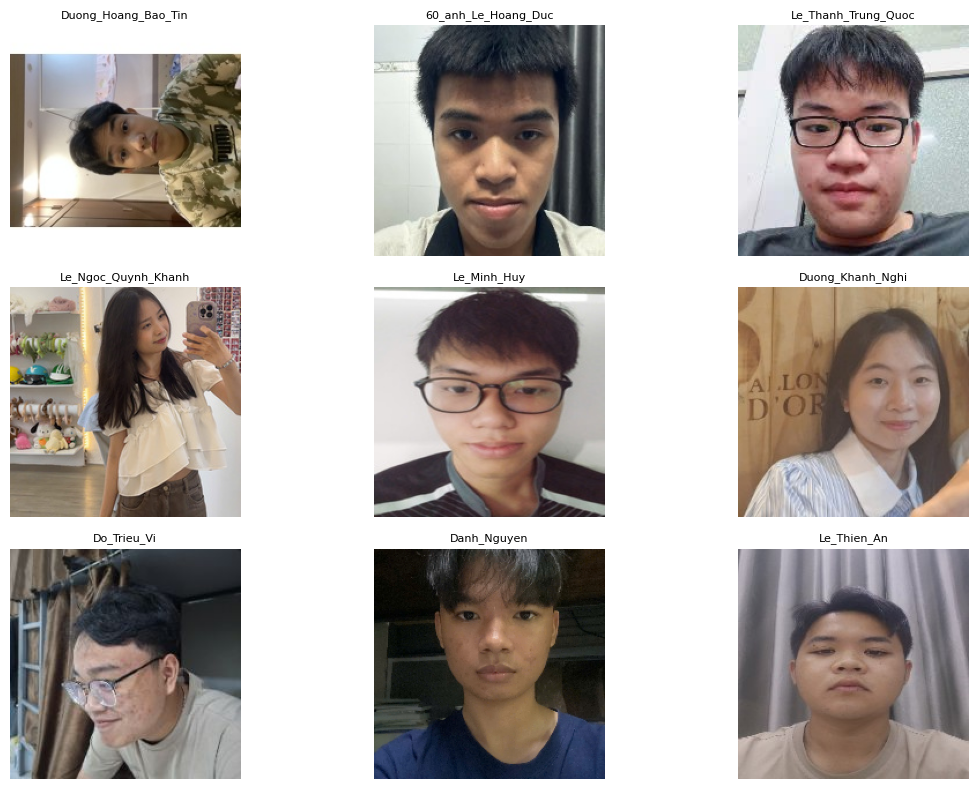

In [4]:
class_names_preview = sorted([p.name for p in DATASET_DIR.iterdir() if p.is_dir()])
plt.figure(figsize=(12, 8))

sample_classes = random.sample(class_names_preview, min(9, len(class_names_preview)))
for i, cls in enumerate(sample_classes, start=1):
    imgs = [p for p in (DATASET_DIR / cls).glob('*') if is_image_file(p)]
    img_path = random.choice(imgs)
    img = Image.open(img_path).convert('RGB')
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(cls, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Bước 5: Chia train / validation / test

Tỉ lệ mặc định:
- Train: 70%
- Validation: 15%
- Test: 15%

In [5]:
SPLIT_DIR = Path('/content/face_dataset_split')
if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

TRAIN_DIR = SPLIT_DIR / 'train'
VAL_DIR = SPLIT_DIR / 'validation'
TEST_DIR = SPLIT_DIR / 'test'
for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

all_paths = []
all_labels = []
for cls in sorted(counts.keys()):
    for img_path in sorted((DATASET_DIR / cls).glob('*')):
        if img_path.is_file() and is_image_file(img_path):
            all_paths.append(str(img_path))
            all_labels.append(cls)

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, random_state=SEED, stratify=all_labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=SEED, stratify=temp_labels
)

def copy_split(paths, labels, target_root):
    for src, label in zip(paths, labels):
        src = Path(src)
        out_dir = target_root / label
        out_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, out_dir / src.name)

copy_split(train_paths, train_labels, TRAIN_DIR)
copy_split(val_paths, val_labels, VAL_DIR)
copy_split(test_paths, test_labels, TEST_DIR)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))
print("Số lớp:", len(set(all_labels)))

Train: 1614
Validation: 346
Test: 347
Số lớp: 39


## Bước 6: Tạo TensorFlow Dataset

Ảnh sẽ được resize về 224x224 để đưa vào mô hình MobileNetV2.

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Class names:", class_names)
print("Num classes:", num_classes)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 1614 files belonging to 39 classes.
Found 346 files belonging to 39 classes.
Found 347 files belonging to 39 classes.
Class names: ['31251025040_TranNguyenHoangLong', '60_anh_Le_Hoang_Duc', 'DO_DOAN_CONG_DANH_AI', 'Dang_Minh_Khoa', 'Dang_Ngoc_Yen_Nhi', 'Danh_Nguyen', 'Do_Trieu_Vi', 'Duong_Hoang_Bao_Tin', 'Duong_Khanh_Nghi', 'Huynh_Le_Tuan_Hung_AI', 'Huynh_Vu_Khanh_Duy', 'LE_THI_NGOC_HIEU', 'Le_Anh_Hao', 'Le_Dinh_Nghia', 'Le_Minh_Huy', 'Le_Ngoc_Quynh_Khanh', 'Le_Quang_Truong', 'Le_Thanh_Trung_Quoc', 'Le_Thien_An', 'Le_Trung_Truc', 'Mahamongkol_Thai_Thinh', 'NGUYEN_TAN_HAO', 'Nguyen_Duy_Vu', 'Nguyen_Huynh_Le', 'Nguyen_Le_Anh_Khoa', 'Nguyen_Minh_Hoang', 'Nguyen_Trong_Huu', 'Pham_Minh_Nhat', 'Pham_Phu_Tai_LT0001', 'Pham_Phung_Gia_Huy', 'Phan_Minh_Thien', 'QUACH_BAO_VAN', 'Tran_Anh_Khoi_selfie', 'Tran_Nguyen_Phuong_Nam_LT0001', 'Tran_Nhat_Nam', 'Tran_Trung_Kien', 'Trinh_Hoang_Tuan_LT0001', 'Truong_Nhat_Truong_Vinh', 'Vu_Thanh_Thao']
Num classes: 39


## Bước 7: Xây dựng mô hình nhận diện khuôn mặt

Sử dụng **MobileNetV2** pretrained trên ImageNet, sau đó thêm lớp phân loại theo số người trong dataset.

In [7]:
from tensorflow.keras import layers, models

# Augmentation giúp model bớt học vẹt khi ảnh ít hoặc góc mặt thay đổi nhẹ.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='data_augmentation')

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 39)             │        49,959 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,307,943 (8.80 MB)

 Trainable params: 49,959 (195.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Bước 8: Huấn luyện mô hình

Nếu chạy lâu, có thể giảm `EPOCHS = 10`. Nếu accuracy còn thấp, tăng lên `20`.

In [8]:
EPOCHS = 15

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('/content/best_face_model.keras', monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - accuracy: 0.3544 - loss: 2.5901 - val_accuracy: 0.8353 - val_loss: 1.2104
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.8525 - loss: 0.8575 - val_accuracy: 0.9133 - val_loss: 0.6047
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.9250 - loss: 0.4835 - val_accuracy: 0.9364 - val_loss: 0.3985
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.9461 - loss: 0.3292 - val_accuracy: 0.9566 - val_loss: 0.3033
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.9628 - loss: 0.2486 - val_accuracy: 0.9653 - val_loss: 0.2516
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9653 - loss: 0.2022 - val_accuracy: 0.9595 - val_loss: 0.2156
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9802 - loss: 0.1608 - val_accuracy: 0.9538 - val_loss: 0.2049
Epoch 8/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.9765 - loss: 0.1417 - val_accuracy: 0.9682 -

## Bước 9: Vẽ biểu đồ accuracy và loss

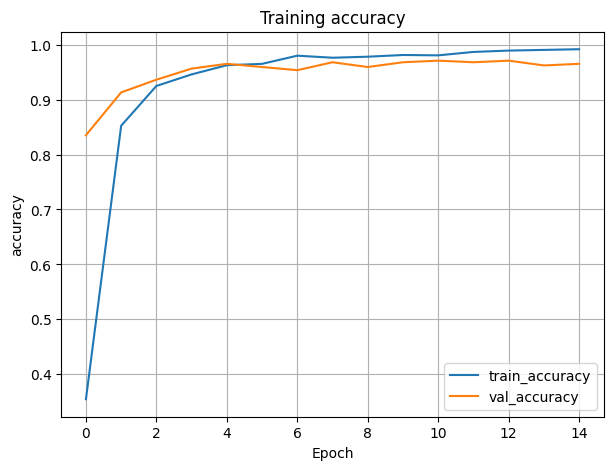

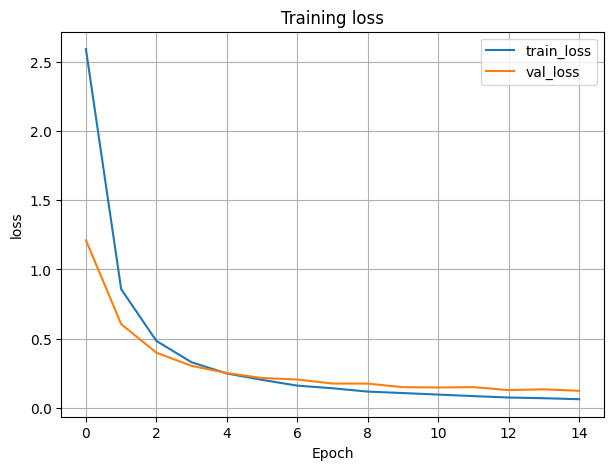

In [9]:
history_df = pd.DataFrame(history.history)
history_df.to_csv('/content/training_history.csv', index=False)

def plot_history(metric):
    plt.figure(figsize=(7, 5))
    plt.plot(history_df[metric], label=f'train_{metric}')
    val_metric = 'val_' + metric
    if val_metric in history_df:
        plt.plot(history_df[val_metric], label=val_metric)
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.title(f'Training {metric}')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history('accuracy')
plot_history('loss')

## Bước 10: Đánh giá trên tập test

Phần này tạo accuracy, classification report và confusion matrix để đưa vào video/báo cáo.

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.9827 - loss: 0.0945
Test loss: 0.0945
Test accuracy: 0.9827
                                 precision    recall  f1-score   support

31251025040_TranNguyenHoangLong     1.0000    1.0000    1.0000         9
            60_anh_Le_Hoang_Duc     1.0000    1.0000    1.0000         9
           DO_DOAN_CONG_DANH_AI     1.0000    1.0000    1.0000         9
                 Dang_Minh_Khoa     1.0000    1.0000    1.0000         9
              Dang_Ngoc_Yen_Nhi     1.0000    1.0000    1.0000         9
                    Danh_Nguyen     0.8182    1.0000    0.9000         9
                    Do_Trieu_Vi     1.0000    1.0000    1.0000         9
            Duong_Hoang_Bao_Tin     1.0000    1.0000    1.0000         9
               Duong_Khanh_Nghi     1.0000    1.0000    1.0000         9
          Huynh_Le_Tuan_Hung_AI     1.0000    1.0000    1.0000        10
             Huynh_Vu_Khanh_Duy     1.0000    0.8889    0.9412         9
         

,true_label,predicted_label,confidence
0,31251025040_TranNguyenHoangLong,31251025040_TranNguyenHoangLong,0.998747
1,31251025040_TranNguyenHoangLong,31251025040_TranNguyenHoangLong,0.998256
2,31251025040_TranNguyenHoangLong,31251025040_TranNguyenHoangLong,0.979116
3,31251025040_TranNguyenHoangLong,31251025040_TranNguyenHoangLong,0.997444
4,31251025040_TranNguyenHoangLong,31251025040_TranNguyenHoangLong,0.998750


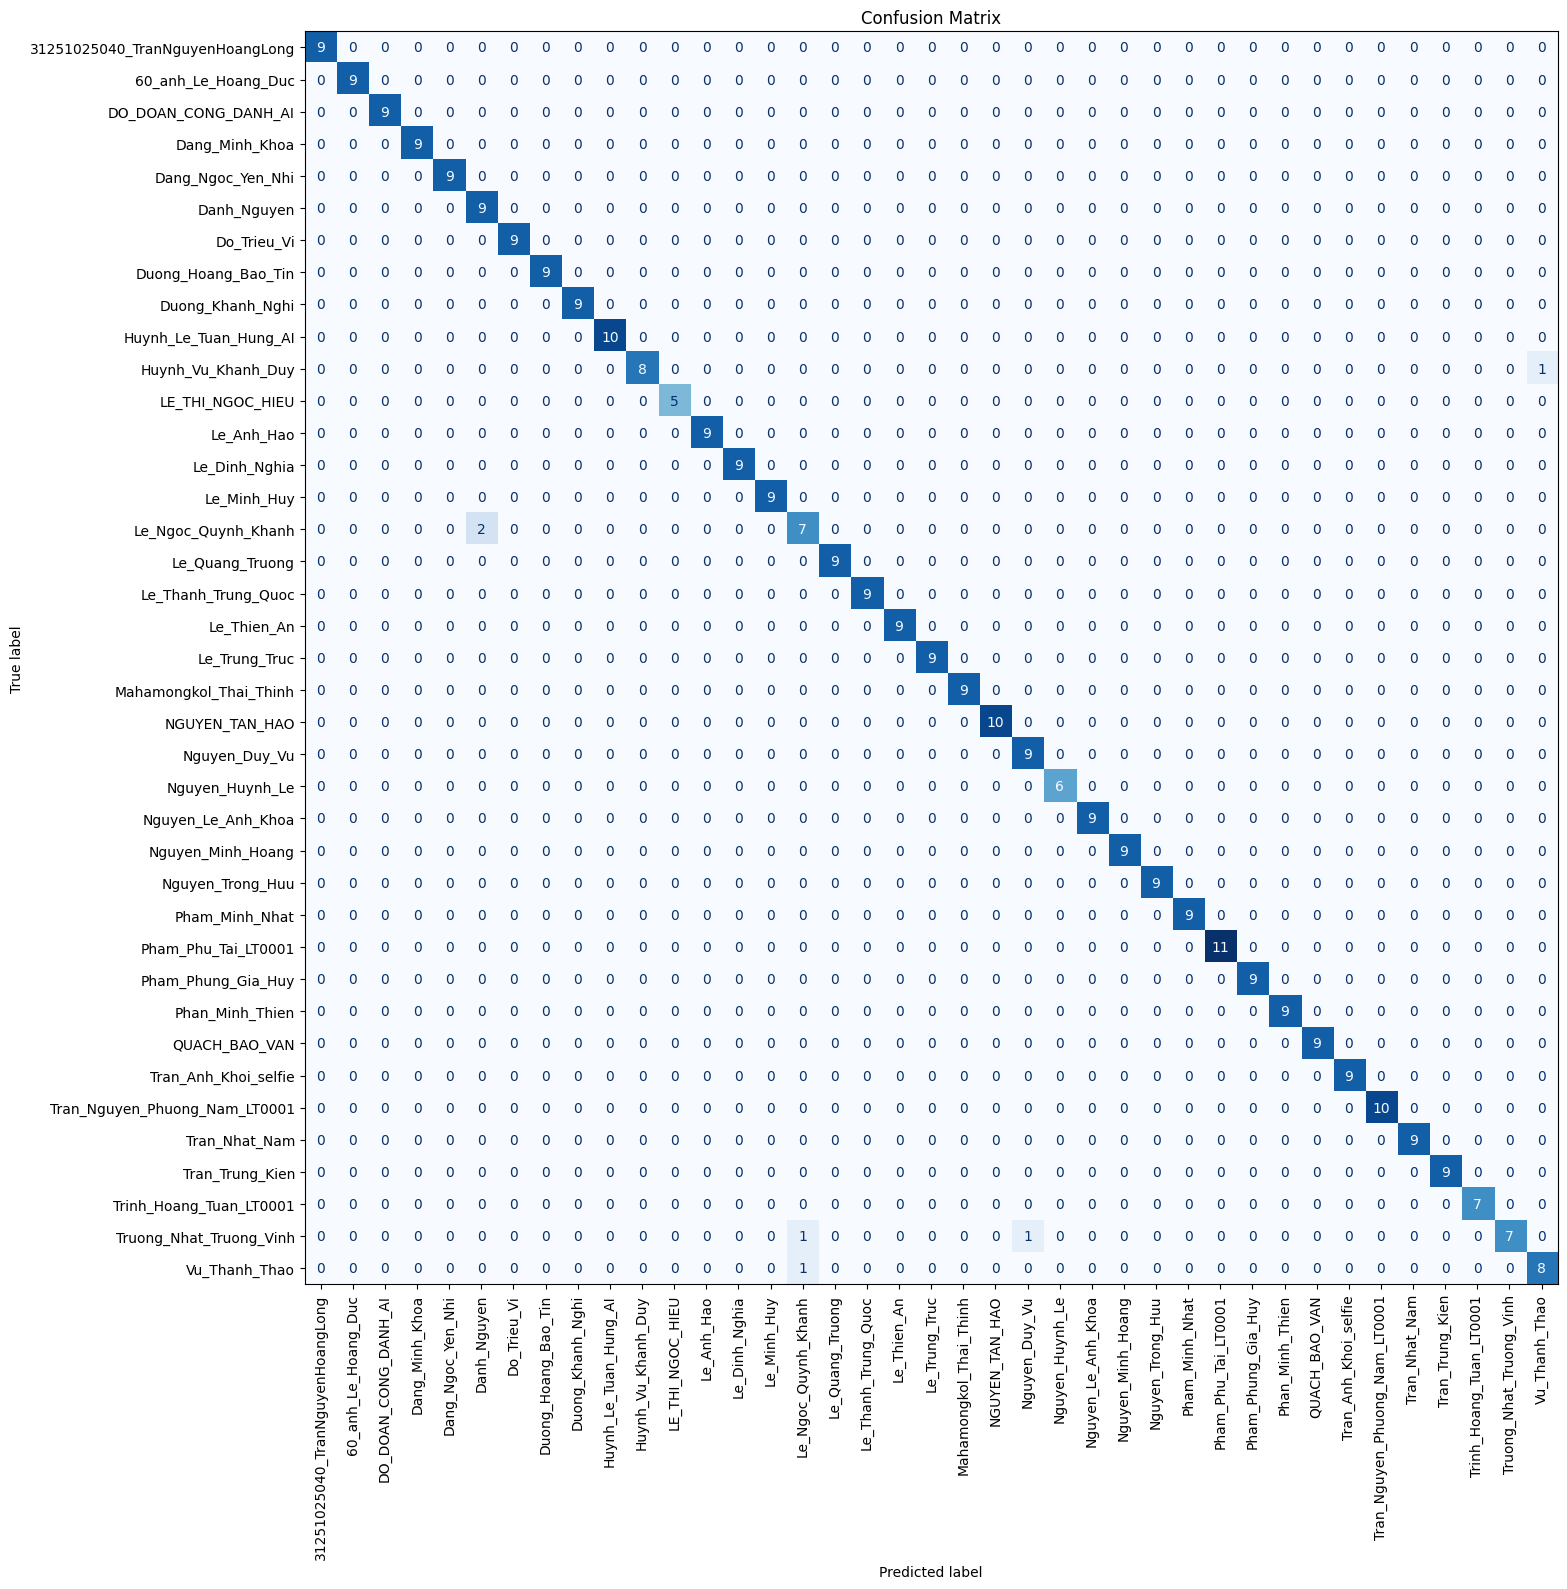

In [10]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

y_true = []
y_pred = []
probs_all = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(probs, axis=1))
    probs_all.extend(np.max(probs, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
probs_all = np.array(probs_all)

report_text = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report_text)
with open('/content/classification_report.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
pd.DataFrame(report_dict).transpose().to_csv('/content/classification_report.csv')

pred_df = pd.DataFrame({
    'true_label': [class_names[i] for i in y_true],
    'predicted_label': [class_names[i] for i in y_pred],
    'confidence': probs_all
})
pred_df.to_csv('/content/test_predictions.csv', index=False)
display(pred_df.head())

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(16, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=90, colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

## Bước 11: Dự đoán thử một ảnh mới

Chọn 1 ảnh khuôn mặt thuộc một trong các người đã train để kiểm tra mô hình.

Hãy upload 1 ảnh để dự đoán thử


Saving IMG_3068.JPG to IMG_3068.JPG


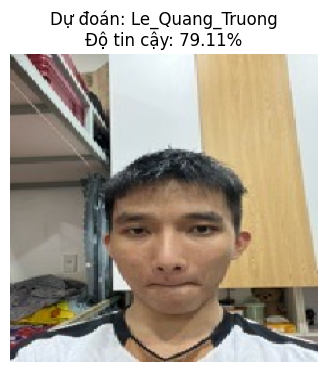

Top dự đoán:
- Le_Quang_Truong: 79.11%
- Truong_Nhat_Truong_Vinh: 6.46%
- Le_Dinh_Nghia: 5.59%
- Nguyen_Le_Anh_Khoa: 5.19%
- Huynh_Vu_Khanh_Duy: 0.98%


In [14]:
from google.colab import files
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# Lấy tên lớp nếu chưa có
try:
    class_names
except NameError:
    class_names = label_names

def predict_one_image(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    arr = tf.keras.utils.img_to_array(img)
    arr_batch = np.expand_dims(arr, axis=0)

    probs = model.predict(arr_batch, verbose=0)[0]
    top_indices = probs.argsort()[-5:][::-1]

    best_idx = top_indices[0]
    best_label = class_names[best_idx]
    confidence = probs[best_idx] * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Dự đoán: {best_label}\nĐộ tin cậy: {confidence:.2f}%")
    plt.show()

    print("Top dự đoán:")
    for idx in top_indices:
        print(f"- {class_names[idx]}: {probs[idx] * 100:.2f}%")

print("Hãy upload 1 ảnh để dự đoán thử")
uploaded_test = files.upload()

for filename in uploaded_test.keys():
    predict_one_image(filename)

## Bước 12: Lưu model và file kết quả

Sau bước này, tải file `face_recognition_results.zip` về để nộp kèm hoặc lưu vào Google Drive.

In [15]:
RESULT_DIR = Path('/content/face_recognition_results')
if RESULT_DIR.exists():
    shutil.rmtree(RESULT_DIR)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Lưu model và nhãn
model.save(RESULT_DIR / 'face_recognition_model.keras')
with open(RESULT_DIR / 'class_names.json', 'w', encoding='utf-8') as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)
with open(RESULT_DIR / 'label_map.json', 'w', encoding='utf-8') as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

# Lưu các file đánh giá
for file_name in [
    'training_history.csv',
    'dataset_stats.csv',
    'classification_report.txt',
    'classification_report.csv',
    'test_predictions.csv',
    'confusion_matrix.png'
]:
    src = Path('/content') / file_name
    if src.exists():
        shutil.copy2(src, RESULT_DIR / file_name)

# Nén kết quả
shutil.make_archive('/content/face_recognition_results', 'zip', RESULT_DIR)
print("Đã tạo file: /content/face_recognition_results.zip")

files.download('/content/face_recognition_results.zip')

Đã tạo file: /content/face_recognition_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>